# Analisis Explainability pada Model Forecasting Kebutuhan Listrik

Pada Tugas ini dilakukan analisis terhadap model forecasting time series menggunakan library Skforecast dan algoritma LightGBM. Selain membuat prediksi kebutuhan listrik, dilakukan juga analisis untuk mengetahui fitur apa saja yang berpengaruh terhadap hasil prediksi menggunakan metode SHAP, Permutation Importance, dan Partial Dependence Plot.

In [ ]:
# Libraries
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay

from lightgbm import LGBMRegressor

!pip install skforecast==0.15.1

from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

## Mengambil Dataset

Dataset yang digunakan merupakan dataset konsumsi listrik wilayah Victoria, Australia. Dataset ini sudah tersedia pada library Skforecast sehingga dapat langsung digunakan tanpa perlu mengunduh secara manual.

In [2]:
# Download data
# ==============================================================================
data = fetch_dataset(name="vic_electricity")
data.head(3)

vic_electricity
---------------
Half-hourly electricity demand for Victoria, Australia
O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse
Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,
https://github.com/tidyverts/tsibbledata/.
https://tsibbledata.tidyverts.org/reference/vic_elec.html
Shape of the dataset: (52608, 4)


,Demand,Temperature,Date,Holiday
Time,,,,
2011-12-31 13:00:00,4382.825174,21.40,2012-01-01,True
2011-12-31 13:30:00,4263.365526,21.05,2012-01-01,True
2011-12-31 14:00:00,4048.966046,20.70,2012-01-01,True


## Agregasi Data Harian

Data asli memiliki frekuensi yang cukup rapat. Agar proses forecasting lebih sederhana, data diubah menjadi frekuensi harian. Nilai Demand dijumlahkan setiap hari, sedangkan Temperature dihitung rata-ratanya.

In [3]:
# Aggregation to daily frequency
# ==============================================================================
data = data.resample('D').agg({'Demand': 'sum', 'Temperature': 'mean'})
data.head(3)

,Demand,Temperature
Time,,
2011-12-31,82531.745918,21.047727
2012-01-01,227778.257304,26.578125
2012-01-02,275490.988882,31.751042


## Membagi Data Training dan Testing

Data dibagi menjadi dua bagian. Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk melakukan prediksi pada periode yang belum pernah dilihat model sebelumnya.

In [4]:
# Split train-test
# ==============================================================================
data_train = data.loc[: '2014-12-21']
data_test = data.loc['2014-12-22':]

## Membuat Model Forecasting

Model yang digunakan adalah LightGBM yang dibungkus menggunakan ForecasterRecursive. Nilai lag sebanyak 7 menunjukkan bahwa model memanfaatkan data 7 hari sebelumnya untuk memprediksi kebutuhan listrik hari berikutnya.

In [5]:
# Create a recursive multi-step forecaster (ForecasterRecursive)
# ==============================================================================
forecaster = ForecasterRecursive(
                 regressor = LGBMRegressor(random_state=123, verbose=-1),
                 lags      = 7
             )

forecaster.fit(
    y    = data_train['Demand'],
    exog = data_train['Temperature']
)
forecaster

=================== 
ForecasterRecursive 
=================== 
Regressor: LGBMRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: None 
Window size: 7 
Exogenous included: True 
Exogenous names: Temperature 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2011-12-31 00:00:00'), Timestamp('2014-12-21 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 123, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-06-10 13:00:43 
Last fit date: 2026-06-10 13:00:43 
Skforecast version: 0.15.1 
Python version: 3.12.13 
Forecaster id: None

## Melihat Feature Importance

Feature importance digunakan untuk melihat fitur mana yang paling sering digunakan oleh model dalam menghasilkan prediksi.

In [6]:
# Predictors importances
# ==============================================================================
forecaster.get_feature_importances()

,feature,importance
7,Temperature,570
0,lag_1,470
2,lag_3,387
1,lag_2,362
6,lag_7,325
5,lag_6,313
4,lag_5,298
3,lag_4,275


## Membentuk Data Training Internal

Pada tahap ini ditampilkan bentuk data yang sebenarnya digunakan model saat proses training. Data time series akan diubah menjadi bentuk tabular dengan fitur lag dan variabel temperatur.

In [7]:
# Training matrices used by the forecaster to fit the internal regressor
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )

display(X_train.head(3))
display(y_train.head(3))

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
Time,,,,,,,,
2012-01-07,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,82531.745918,24.098958
2012-01-08,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,20.223958
2012-01-09,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,19.161458


,y
Time,
2012-01-07,200693.270298
2012-01-08,200061.614738
2012-01-09,216201.836844


## Analisis Menggunakan SHAP

SHAP digunakan untuk menjelaskan kontribusi masing-masing fitur terhadap hasil prediksi model. Dengan metode ini dapat diketahui apakah suatu fitur meningkatkan atau menurunkan hasil prediksi.

In [8]:
# Create SHAP explainer
# ==============================================================================
shap.initjs()
explainer = shap.TreeExplainer(forecaster.regressor)
shap_values = explainer.shap_values(X_train)

## SHAP Summary Plot

Visualisasi berikut menunjukkan urutan fitur berdasarkan tingkat pengaruhnya terhadap model secara keseluruhan.

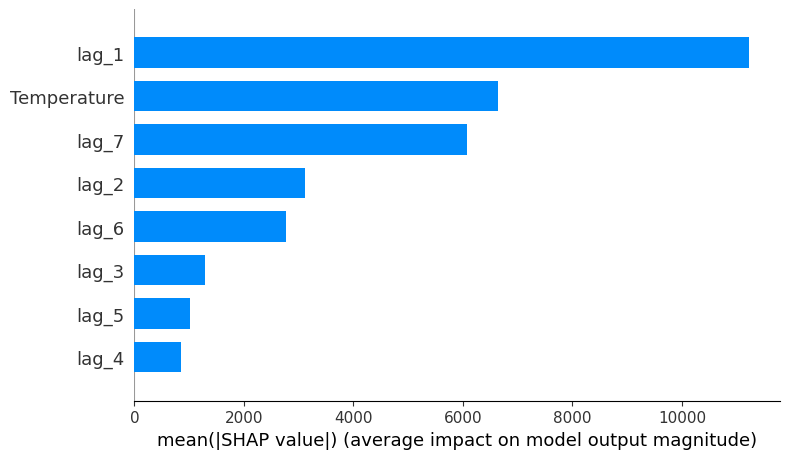

In [9]:
shap.summary_plot(
    shap_values,
    X_train,
    plot_type="bar"
)

## SHAP Summary Plot Detail

Plot ini menunjukkan distribusi pengaruh setiap fitur terhadap prediksi. Warna menunjukkan besar kecilnya nilai fitur, sedangkan posisi menunjukkan arah pengaruhnya.

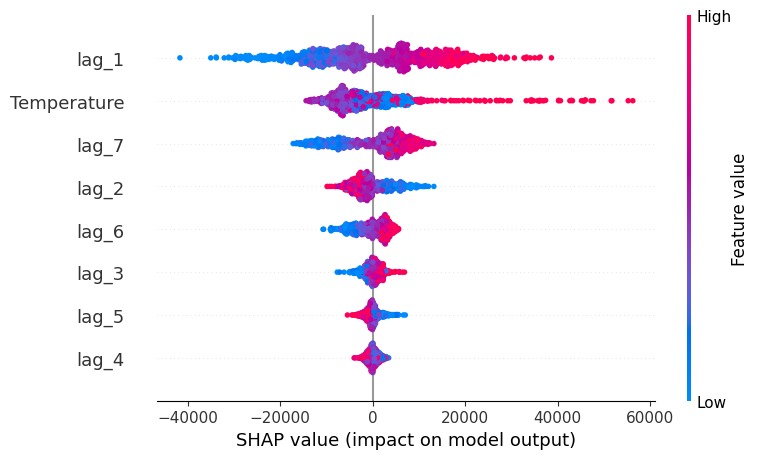

In [10]:
shap.summary_plot(
    shap_values,
    X_train
)

## Force Plot untuk Satu Observasi

Visualisasi ini digunakan untuk melihat alasan model menghasilkan suatu prediksi tertentu pada satu data.

In [11]:
import shap
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[0, :],
    X_train.iloc[0, :]
)

## Force Plot untuk Banyak Observasi

Visualisasi ini memperlihatkan pola kontribusi fitur terhadap sejumlah observasi sekaligus.

In [12]:
import shap
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[:200, :],
    X_train.iloc[:200, :]
)

## Dependence Plot

Dependence plot digunakan untuk melihat hubungan antara nilai suatu fitur dengan kontribusinya terhadap prediksi model.

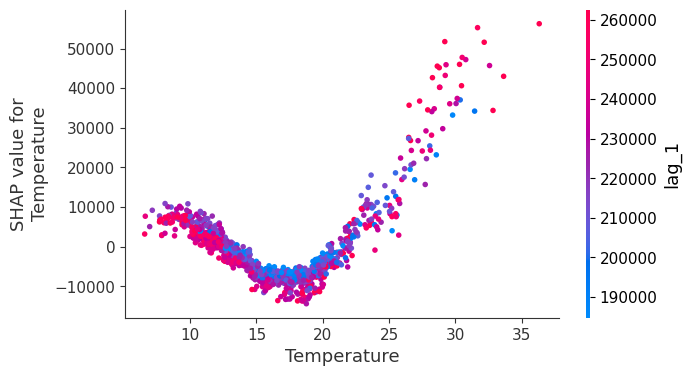

In [13]:
# Dependence plot for Temperature
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 4))

shap.dependence_plot(
    "Temperature",
    shap_values,
    X_train,
    ax=ax
)

## Melakukan Prediksi

Setelah model selesai dilatih, langkah berikutnya adalah melakukan prediksi untuk beberapa hari ke depan. Pada contoh ini dilakukan prediksi sebanyak 10 hari menggunakan data temperatur yang tersedia pada data testing.

In [14]:
# Predict
# ==============================================================================
predictions = forecaster.predict(
    steps=10,
    exog=data_test['Temperature']
)

predictions

,pred
2014-12-22,241514.532543
2014-12-23,226165.936559
2014-12-24,220506.468700
2014-12-25,209260.948991
2014-12-26,184885.145832
2014-12-27,195623.591810
2014-12-28,222766.340659
2014-12-29,223112.716406
2014-12-30,219103.891733
2014-12-31,217948.965404


## Membentuk Data Input Prediksi

Skforecast menyediakan fungsi untuk melihat data input yang digunakan model saat melakukan prediksi. Dengan cara ini kita dapat memahami fitur apa saja yang menjadi dasar pengambilan keputusan model.

In [15]:
# Create input matrix for predict method
# ==============================================================================
X_predict = forecaster.create_predict_X(
    steps=10,
    exog=data_test['Temperature']
)

X_predict

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
2014-12-22,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,231923.044018,22.950000
2014-12-23,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,18.829167
2014-12-24,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,18.312500
2014-12-25,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,16.933333
2014-12-26,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,16.429167
2014-12-27,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,18.189583
2014-12-28,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,24.539583
2014-12-29,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,17.677083
2014-12-30,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,17.391667
2014-12-31,219103.891733,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,21.034615


## Menjelaskan Salah Satu Hasil Prediksi

Pada tahap ini dilakukan analisis terhadap satu hasil prediksi tertentu menggunakan SHAP. Tujuannya adalah untuk mengetahui faktor apa saja yang mendorong nilai prediksi menjadi lebih tinggi atau lebih rendah.

In [16]:
# Force plot for a specific prediction
# ==============================================================================

import shap
shap.initjs()

predicted_date = '2014-12-22'

iloc_predicted_date = X_predict.index.get_loc(
    predicted_date
)

shap_values = explainer.shap_values(X_predict)

shap.force_plot(
    explainer.expected_value,
    shap_values[iloc_predicted_date, :],
    X_predict.iloc[iloc_predicted_date, :]
)

## Permutation Importance

Selain menggunakan SHAP, dilakukan juga analisis menggunakan Permutation Importance. Metode ini bekerja dengan cara mengacak nilai suatu fitur kemudian melihat seberapa besar penurunan performa model yang terjadi.

Semakin besar penurunan performanya, maka semakin penting fitur tersebut bagi model.

In [17]:
# Training matrices used by the forecaster to fit the internal regressor
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )

# Permutation importances
# ==============================================================================

r = permutation_importance(
    estimator=forecaster.regressor,
    X=X_train,
    y=y_train,
    n_repeats=3,
    max_samples=0.5,
    random_state=123
)

importances = pd.DataFrame({
    'feature': X_train.columns,
    'mean_importance': r.importances_mean,
    'std_importance': r.importances_std
}).sort_values(
    'mean_importance',
    ascending=False
)

importances

,feature,mean_importance,std_importance
0,lag_1,0.617276,0.014583
7,Temperature,0.411240,0.014405
6,lag_7,0.196190,0.001865
1,lag_2,0.122398,0.007803
5,lag_6,0.083912,0.003637
2,lag_3,0.041294,0.002019
4,lag_5,0.030787,0.001079
3,lag_4,0.024816,0.001021


## Partial Dependence Plot

Partial Dependence Plot digunakan untuk melihat hubungan rata-rata antara suatu fitur dan hasil prediksi model. Visualisasi ini membantu memahami bagaimana perubahan nilai fitur mempengaruhi output model.

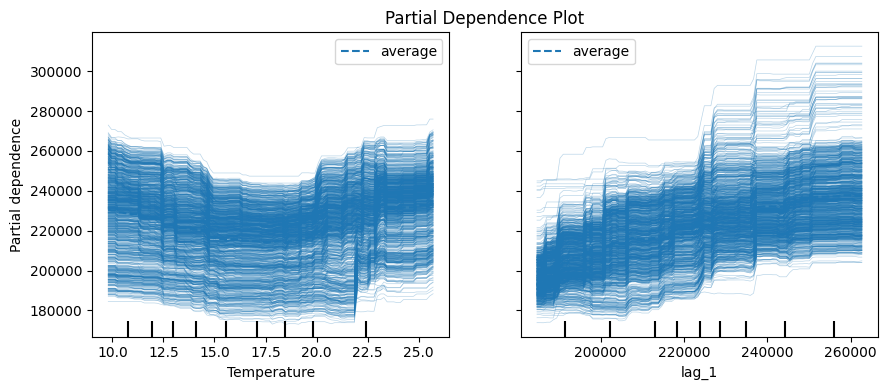

In [18]:
# Scikit-learn partial dependence plots
# ==============================================================================

fig, ax = plt.subplots(figsize=(9, 4))

ax.set_title("Decision Tree")

PartialDependenceDisplay.from_estimator(
    estimator=forecaster.regressor,
    X=X_train,
    features=["Temperature", "lag_1"],
    kind='both',
    ax=ax,
)

ax.set_title("Partial Dependence Plot")
fig.tight_layout()

## Jawaban dan Pembahasan

### 1. Prediksi dilakukan terhadap apa?

Pada praktikum ini, model digunakan untuk memprediksi kebutuhan listrik harian (Demand) di Victoria, Australia. Prediksi dibuat berdasarkan data penggunaan listrik pada hari-hari sebelumnya serta data temperatur harian.

### 2. Bagaimana bentuk data training yang digunakan?

Sebelum digunakan untuk melatih model, data time series diubah terlebih dahulu menjadi bentuk tabel.

#### Input (X)

Data yang digunakan sebagai input yaitu:

- lag_1
- lag_2
- lag_3
- lag_4
- lag_5
- lag_6
- lag_7
- Temperature

#### Output (y)

Data yang diprediksi adalah:

- Demand atau kebutuhan listrik pada hari berikutnya.

Jadi, model belajar dari data penggunaan listrik selama 7 hari sebelumnya dan temperatur untuk memprediksi kebutuhan listrik pada hari selanjutnya.

### 3. Apa yang dimaksud dengan lag?

Lag adalah data dari periode sebelumnya yang digunakan sebagai acuan untuk melakukan prediksi.

Contohnya:

- lag_1 = kebutuhan listrik 1 hari yang lalu
- lag_2 = kebutuhan listrik 2 hari yang lalu
- lag_3 = kebutuhan listrik 3 hari yang lalu

Pada percobaan ini digunakan 7 lag, artinya model melihat data kebutuhan listrik selama 7 hari terakhir sebelum membuat prediksi.

### 4. Jelaskan proses analisis yang dilakukan pada kasus ini

Tahapan yang dilakukan dalam analisis ini adalah:

1. Mengambil dataset kebutuhan listrik Victoria.
2. Mengubah data menjadi data harian.
3. Membagi data menjadi data training dan testing.
4. Membuat model forecasting menggunakan LightGBM.
5. Menggunakan data lag dan temperatur sebagai fitur.
6. Melatih model menggunakan data training.
7. Melakukan prediksi untuk beberapa hari ke depan.
8. Menggunakan SHAP untuk melihat faktor yang mempengaruhi hasil prediksi.
9. Menggunakan Permutation Importance untuk mengetahui fitur yang paling penting.
10. Menggunakan Partial Dependence Plot untuk melihat hubungan antara fitur dan hasil prediksi.

Dari hasil analisis terlihat bahwa penggunaan listrik pada hari-hari sebelumnya serta temperatur memiliki pengaruh yang cukup besar terhadap hasil prediksi model.

## Kesimpulan

Model yang dibuat dapat digunakan untuk memprediksi kebutuhan listrik berdasarkan pola penggunaan listrik sebelumnya dan temperatur harian. Hasil analisis juga menunjukkan bahwa fitur lag dan temperatur merupakan faktor yang paling berpengaruh dalam proses prediksi.